PART 2: DATA INSPECTION

Import libraries


In [1]:
import pandas as pd
pd.set_option('display.max_columns',None)

loading the dataset


In [2]:
df = pd.read_csv('heart.csv')
df.shape

(918, 12)

Display the first 10 rows

In [3]:
df.head(10)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
5,39,M,NAP,120,339,0,Normal,170,N,0.0,Up,0
6,45,F,ATA,130,237,0,Normal,170,N,0.0,Up,0
7,54,M,ATA,110,208,0,Normal,142,N,0.0,Up,0
8,37,M,ASY,140,207,0,Normal,130,Y,1.5,Flat,1
9,48,F,ATA,120,284,0,Normal,120,N,0.0,Up,0


Structure and data types

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 97.6 KB


Missing values

In [5]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

Duplicate rows

In [6]:
df.duplicated().sum()

np.int64(0)

Descriptive statistics

In [7]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,918.0,NaN,NaN,NaN,53.510893,9.432617,28.0,47.0,54.0,60.0,77.0
Sex,918,2,M,725,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ChestPainType,918,4,ASY,496,NaN,NaN,NaN,NaN,NaN,NaN,NaN
RestingBP,918.0,NaN,NaN,NaN,132.396514,18.514154,0.0,120.0,130.0,140.0,200.0
Cholesterol,918.0,NaN,NaN,NaN,198.799564,109.384145,0.0,173.25,223.0,267.0,603.0
FastingBS,918.0,NaN,NaN,NaN,0.233115,0.423046,0.0,0.0,0.0,0.0,1.0
RestingECG,918,3,Normal,552,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MaxHR,918.0,NaN,NaN,NaN,136.809368,25.460334,60.0,120.0,138.0,156.0,202.0
ExerciseAngina,918,2,N,547,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Oldpeak,918.0,NaN,NaN,NaN,0.887364,1.06657,-2.6,0.0,0.6,1.5,6.2


PART 3: Feature Engineering & Data Preprocessing

Data Cleaning: 


In [8]:
#RestingBP and Cholesterol are two columns where a value of 0 is medically impossible in a living person. Therefore, zero likely represents missing values.

print("RestingBP = 0:", (df['RestingBP'] ==0).sum())
print("Cholesterol = 0:", (df['Cholesterol'] ==0).sum())

RestingBP = 0: 1
Cholesterol = 0: 172


Missing Values

In [9]:
#Coverting the disguised zeros into real missing values

import numpy as np

df['RestingBP'] = df['RestingBP'].replace(0, np.nan)
df['Cholesterol'] = df['Cholesterol'].replace(0, np.nan)

df.isnull().sum()

Age                 0
Sex                 0
ChestPainType       0
RestingBP           1
Cholesterol       172
FastingBS           0
RestingECG          0
MaxHR               0
ExerciseAngina      0
Oldpeak             0
ST_Slope            0
HeartDisease        0
dtype: int64

In [10]:
df = df.drop(columns=['cholesterol'], errors='ignore')

In [11]:
#Handling the missing values

df['RestingBP'] = df['RestingBP'].fillna(df['RestingBP'].median())
df['Cholesterol'] = df['Cholesterol'].fillna(df['Cholesterol'].median())

df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

Remove duplicates

In [12]:
df = df.drop_duplicates()
df.shape

(918, 12)

Correct Data types

In [13]:
df.dtypes

Age                 int64
Sex                   str
ChestPainType         str
RestingBP         float64
Cholesterol       float64
FastingBS           int64
RestingECG            str
MaxHR               int64
ExerciseAngina        str
Oldpeak           float64
ST_Slope              str
HeartDisease        int64
dtype: object

Part 3: Feature Engineering

Rename Columns

In [14]:
#checking current column names

df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='str')

In [15]:
#Most of these column names are already fairly clear. The following were renamed to make them more understandable

df = df.rename(columns={
    'FastingBS': 'FastingBloodSugar',
    'RestingBP': 'RestingBloodPressure',
    'RestingECG': 'RestingECGResult',
    'MaxHR': 'MaxHeartRate'
})
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBloodPressure', 'Cholesterol',
       'FastingBloodSugar', 'RestingECGResult', 'MaxHeartRate',
       'ExerciseAngina', 'Oldpeak', 'ST_Slope', 'HeartDisease'],
      dtype='str')

Create a New Feature

In [16]:
#New Feature: AgeGroup, since risk is not linear with age and a categorical grouping can sometimes reveal patterns a raw number doesn't.

df['AgeGroup'] = pd.cut(df['Age'],
                          bins=[0, 40, 50, 60, 100],
                          labels=['Under 40', '40-50', '50-60', '60+'])
df[['Age', 'AgeGroup']].head(10)


,Age,AgeGroup
0,40,Under 40
1,49,40-50
2,37,Under 40
3,48,40-50
4,54,50-60
5,39,Under 40
6,45,40-50
7,54,50-60
8,37,Under 40
9,48,40-50


Removal of irrelevant features

In [17]:
for c in df.columns:
    print(c, "->", df[c].nunique(), "unique values")

Age -> 50 unique values
Sex -> 2 unique values
ChestPainType -> 4 unique values
RestingBloodPressure -> 66 unique values
Cholesterol -> 221 unique values
FastingBloodSugar -> 2 unique values
RestingECGResult -> 3 unique values
MaxHeartRate -> 119 unique values
ExerciseAngina -> 2 unique values
Oldpeak -> 53 unique values
ST_Slope -> 3 unique values
HeartDisease -> 2 unique values
AgeGroup -> 4 unique values


Feature Encoding

Technique: Label Encoding and One-Hot Encoding

Label Encoding assigns each category a number (0, 1, 2...), but numbers imply order, so a model might wrongly assume a category with a higher number is "greater than" one with a lower number. For binary columns like Sex (M/F) or ExerciseAngina (Y/N), this isn't a problem, since there are only two options and no in-between value to misinterpret, so Label Encoding is fine and keeps things simple. But for columns like ChestPainType, which has four unrelated categories (ASY, ATA, NAP, TA), Label Encoding would falsely imply one type of chest pain is "more" than another, which isn't true. One-Hot Encoding avoids this by creating a separate 0/1 column for each category, so the model treats them as independent options rather than ranked values. The rule of thumb: use Label Encoding for binary columns or genuinely ordered categories (like a 1 - 4 satisfaction scale), and use One-Hot Encoding for multi-category columns with no real order.

In [18]:
#Label Encode the binary columns

df['Sex'] = df['Sex'].map({'M': 1, 'F': 0})
df['ExerciseAngina'] = df['ExerciseAngina'].map({'Y': 1, 'N': 0})

df[['Sex', 'ExerciseAngina']].head(10)

,Sex,ExerciseAngina
0,1,0
1,0,0
2,1,0
3,0,1
4,1,0
5,1,0
6,0,0
7,1,0
8,1,1
9,0,0


In [19]:
#One-Hot Encode the multi-category columns

df = pd.get_dummies(df, columns=['ChestPainType', 'RestingECGResult', 'ST_Slope', 'AgeGroup'],
                     drop_first=True)
df.head(10)

,Age,Sex,RestingBloodPressure,Cholesterol,FastingBloodSugar,MaxHeartRate,ExerciseAngina,Oldpeak,HeartDisease,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECGResult_Normal,RestingECGResult_ST,ST_Slope_Flat,ST_Slope_Up,AgeGroup_40-50,AgeGroup_50-60,AgeGroup_60+
0,40,1,140.0,289.0,0,172,0,0.0,0,True,False,False,True,False,False,True,False,False,False
1,49,0,160.0,180.0,0,156,0,1.0,1,False,True,False,True,False,True,False,True,False,False
2,37,1,130.0,283.0,0,98,0,0.0,0,True,False,False,False,True,False,True,False,False,False
3,48,0,138.0,214.0,0,108,1,1.5,1,False,False,False,True,False,True,False,True,False,False
4,54,1,150.0,195.0,0,122,0,0.0,0,False,True,False,True,False,False,True,False,True,False
5,39,1,120.0,339.0,0,170,0,0.0,0,False,True,False,True,False,False,True,False,False,False
6,45,0,130.0,237.0,0,170,0,0.0,0,True,False,False,True,False,False,True,True,False,False
7,54,1,110.0,208.0,0,142,0,0.0,0,True,False,False,True,False,False,True,False,True,False
8,37,1,140.0,207.0,0,130,1,1.5,1,False,False,False,True,False,True,False,False,False,False
9,48,0,120.0,284.0,0,120,0,0.0,0,True,False,False,True,False,False,True,True,False,False


Feature Scaling

In [20]:
#Identifying which columns need scaling, binary/dummy 0-1 columns do not need scaling, since those are on a comparable scale

numeric_cols = ['Age', 'RestingBloodPressure', 'Cholesterol', 'MaxHeartRate', 'Oldpeak']
df[numeric_cols].describe()


,Age,RestingBloodPressure,Cholesterol,MaxHeartRate,Oldpeak
count,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.538126,243.204793,136.809368,0.887364
std,9.432617,17.990127,53.401297,25.460334,1.066570
min,28.000000,80.000000,85.000000,60.000000,-2.600000
25%,47.000000,120.000000,214.000000,120.000000,0.000000
50%,54.000000,130.000000,237.000000,138.000000,0.600000
75%,60.000000,140.000000,267.000000,156.000000,1.500000
max,77.000000,200.000000,603.000000,202.000000,6.200000


Application: StandardScaler

StandardScaler is the standard choice for continuous medical measurements like these since it transforms each column to have a mean of 0 and standard deviation of 1, which works well when data is roughly normally distributed and is not dominated by extreme outliers.

In [21]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

df[numeric_cols].describe()

,Age,RestingBloodPressure,Cholesterol,MaxHeartRate,Oldpeak
count,9.180000e+02,9.180000e+02,9.180000e+02,9.180000e+02,9.180000e+02
mean,-1.083616e-16,1.760877e-16,2.399436e-16,4.953675e-16,1.238419e-16
std,1.000545e+00,1.000545e+00,1.000545e+00,1.000545e+00,1.000545e+00
min,-2.706015e+00,-2.921979e+00,-2.964180e+00,-3.018469e+00,-3.271482e+00
25%,-6.906294e-01,-6.973248e-01,-5.471911e-01,-6.605778e-01,-8.324324e-01
50%,5.188098e-02,-1.411613e-01,-1.162551e-01,4.678968e-02,-2.695748e-01
75%,6.883185e-01,4.150021e-01,4.458352e-01,7.541571e-01,5.747115e-01
max,2.491558e+00,3.751983e+00,6.741247e+00,2.561874e+00,4.983762e+00


Outlier Detection

Boxplots

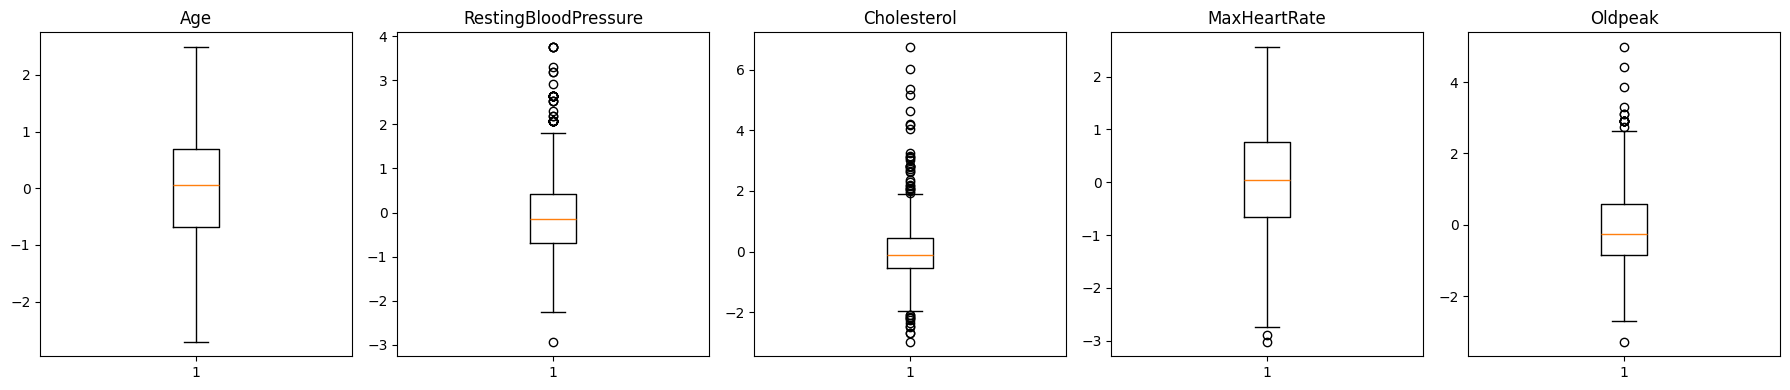

In [23]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 5, figsize=(18, 4))

for i, col in enumerate(numeric_cols):
    axes[i].boxplot(df[col])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

IQR Method 

In [24]:
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {len(outliers)} outliers")

Age: 0 outliers
RestingBloodPressure: 41 outliers
Cholesterol: 41 outliers
MaxHeartRate: 2 outliers
Oldpeak: 16 outliers


In [25]:
#Cap the outliers

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower=lower, upper=upper)

# Confirm no outliers remain
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {len(outliers)} outliers")

Age: 0 outliers
RestingBloodPressure: 0 outliers
Cholesterol: 0 outliers
MaxHeartRate: 0 outliers
Oldpeak: 0 outliers


In [26]:
df.shape

(918, 19)

In [27]:
df.head()

,Age,Sex,RestingBloodPressure,Cholesterol,FastingBloodSugar,MaxHeartRate,ExerciseAngina,Oldpeak,HeartDisease,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECGResult_Normal,RestingECGResult_ST,ST_Slope_Flat,ST_Slope_Up,AgeGroup_40-50,AgeGroup_50-60,AgeGroup_60+
0,-1.433140,1,0.415002,0.858035,0,1.382928,0,-0.832432,0,True,False,False,True,False,False,True,False,False,False
1,-0.478484,0,1.527329,-1.184227,0,0.754157,0,0.105664,1,False,True,False,True,False,True,False,True,False,False
2,-1.751359,1,-0.141161,0.745617,0,-1.525138,0,-0.832432,0,True,False,False,False,True,False,True,False,False,False
3,-0.584556,0,0.303769,-0.547191,0,-1.132156,1,0.574711,1,False,False,False,True,False,True,False,True,False,False
4,0.051881,1,0.971166,-0.903182,0,-0.581981,0,-0.832432,0,False,True,False,True,False,False,True,False,True,False


Z-Score

In [28]:
pip install scipy


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [29]:
from scipy import stats

z_scores = df[numeric_cols].apply(stats.zscore)

for col in numeric_cols:
    outliers = (z_scores[col].abs() > 3).sum()
    print(f"{col}: {outliers} outliers (Z-score > 3)")

Age: 0 outliers (Z-score > 3)
RestingBloodPressure: 0 outliers (Z-score > 3)
Cholesterol: 0 outliers (Z-score > 3)
MaxHeartRate: 0 outliers (Z-score > 3)
Oldpeak: 1 outliers (Z-score > 3)


Feature Selection 

In [30]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Most important Features & Highly correlated variables

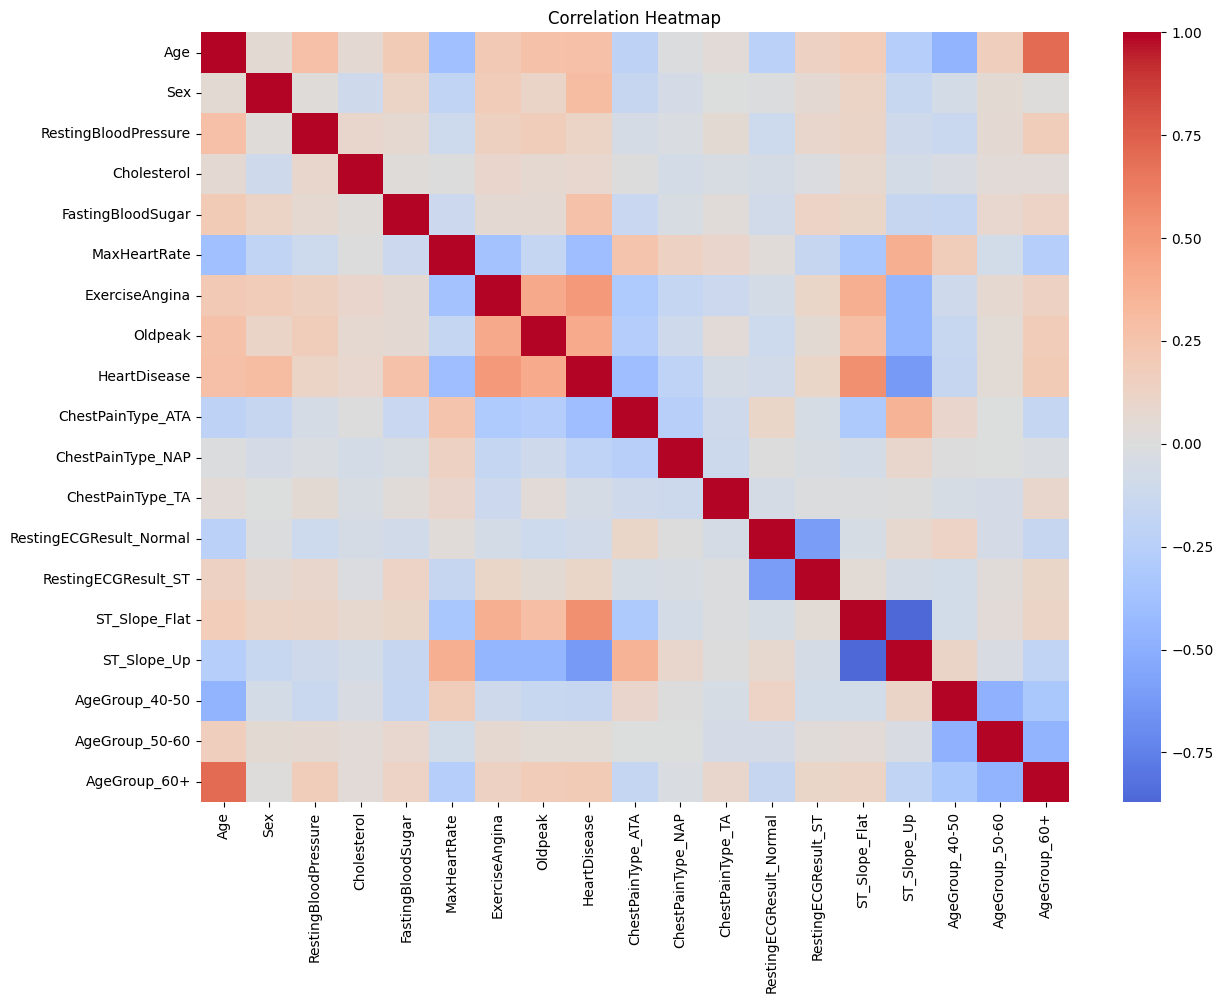

In [31]:
import seaborn as sns

plt.figure(figsize=(14, 10))
sns.heatmap(df.corr(), annot=False, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()

In [32]:
correlations = df.corr()['HeartDisease'].sort_values(ascending=False)
correlations

HeartDisease               1.000000
ST_Slope_Flat              0.554134
ExerciseAngina             0.494282
Oldpeak                    0.410211
Sex                        0.305445
Age                        0.282039
FastingBloodSugar          0.267291
AgeGroup_60+               0.198362
RestingBloodPressure       0.115885
RestingECGResult_ST        0.102527
Cholesterol                0.083381
AgeGroup_50-60             0.049644
ChestPainType_TA          -0.054790
RestingECGResult_Normal   -0.091580
AgeGroup_40-50            -0.155343
ChestPainType_NAP         -0.212964
MaxHeartRate              -0.400519
ChestPainType_ATA         -0.401924
ST_Slope_Up               -0.622164
Name: HeartDisease, dtype: float64

In [33]:
#Checking for redundancy between features themselves

corr_matrix = df.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

high_corr_pairs = [(col, row, upper.loc[row, col]) 
                    for col in upper.columns for row in upper.index 
                    if upper.loc[row, col] > 0.7]

high_corr_pairs

[('ST_Slope_Up', 'ST_Slope_Flat', np.float64(0.8709513170178301)),
 ('AgeGroup_60+', 'Age', np.float64(0.7008256578580548))]

Features that should be removed

In [34]:
#Dropping the AgeGroup I added earlier since Age column carries more precise information

df = df.drop(columns=['AgeGroup_40-50', 'AgeGroup_50-60', 'AgeGroup_60+'])
df.shape

(918, 16)

Cleaned CSV

In [35]:
# Reloading raw data fresh
df_clean = pd.read_csv('heart.csv')

# Fixing disguised missing values
df_clean['RestingBP'] = df_clean['RestingBP'].replace(0, np.nan)
df_clean['Cholesterol'] = df_clean['Cholesterol'].replace(0, np.nan)

# Filling with median
df_clean['RestingBP'] = df_clean['RestingBP'].fillna(df_clean['RestingBP'].median())
df_clean['Cholesterol'] = df_clean['Cholesterol'].fillna(df_clean['Cholesterol'].median())

# Removing duplicates
df_clean = df_clean.drop_duplicates()

# Renaming columns for clarity (matching earlier renames)
df_clean = df_clean.rename(columns={
    'FastingBS': 'FastingBloodSugar',
    'RestingBP': 'RestingBloodPressure',
    'RestingECG': 'RestingECGResult',
    'MaxHR': 'MaxHeartRate'
})

df_clean.info()
df_clean.to_csv('heart_disease_cleaned.csv', index=False)
print("Cleaned dataset saved successfully")

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Age                   918 non-null    int64  
 1   Sex                   918 non-null    str    
 2   ChestPainType         918 non-null    str    
 3   RestingBloodPressure  918 non-null    float64
 4   Cholesterol           918 non-null    float64
 5   FastingBloodSugar     918 non-null    int64  
 6   RestingECGResult      918 non-null    str    
 7   MaxHeartRate          918 non-null    int64  
 8   ExerciseAngina        918 non-null    str    
 9   Oldpeak               918 non-null    float64
 10  ST_Slope              918 non-null    str    
 11  HeartDisease          918 non-null    int64  
dtypes: float64(3), int64(4), str(5)
memory usage: 97.6 KB
Cleaned dataset saved successfully


Part 5: Final Machine Learning Dataset

In [36]:
df.info()
df.isnull().sum().sum()

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      918 non-null    float64
 1   Sex                      918 non-null    int64  
 2   RestingBloodPressure     918 non-null    float64
 3   Cholesterol              918 non-null    float64
 4   FastingBloodSugar        918 non-null    int64  
 5   MaxHeartRate             918 non-null    float64
 6   ExerciseAngina           918 non-null    int64  
 7   Oldpeak                  918 non-null    float64
 8   HeartDisease             918 non-null    int64  
 9   ChestPainType_ATA        918 non-null    bool   
 10  ChestPainType_NAP        918 non-null    bool   
 11  ChestPainType_TA         918 non-null    bool   
 12  RestingECGResult_Normal  918 non-null    bool   
 13  RestingECGResult_ST      918 non-null    bool   
 14  ST_Slope_Flat            918 non-null

np.int64(0)

In [37]:
df.to_csv('heart_disease_ml_ready.csv', index=False)
print("Saved successfully")

Saved successfully


Visualizations

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

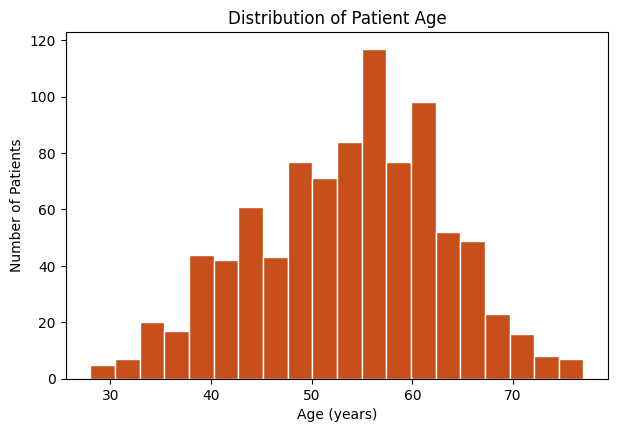

In [46]:
#Histogram: Age Distribution

plt.figure(figsize=(7,4.5))
plt.hist(df_clean['Age'], bins=20, color='#C74F19', edgecolor='white')
plt.xlabel('Age (years)')
plt.ylabel('Number of Patients')
plt.title('Distribution of Patient Age')
plt.show()

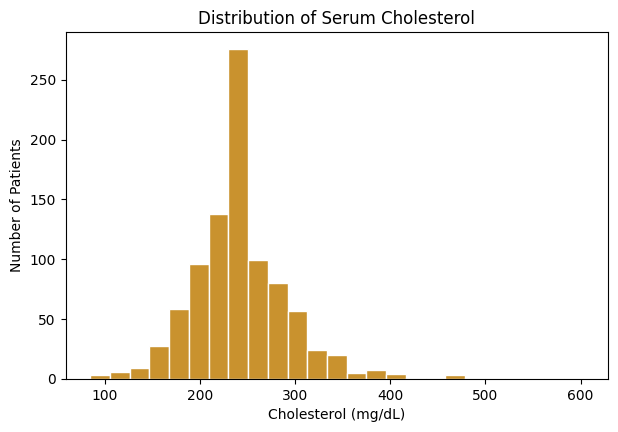

In [47]:
#Histogram: Cholesterol Distribution 

plt.figure(figsize=(7,4.5))
plt.hist(df_clean['Cholesterol'], bins=25, color='#c9922e', edgecolor='white')
plt.xlabel('Cholesterol (mg/dL)')
plt.ylabel('Number of Patients')
plt.title('Distribution of Serum Cholesterol')
plt.show()

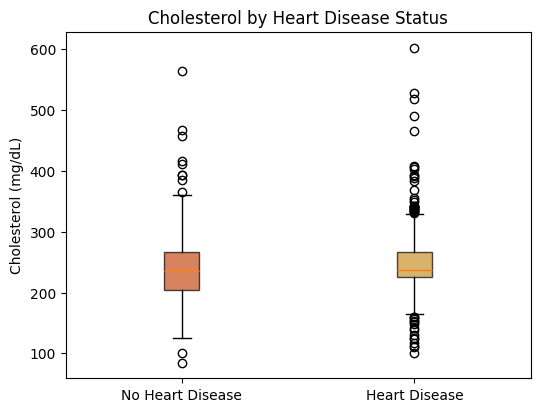

In [48]:
#Boxplot: Cholesterol by Heart Disease Status

data = [df_clean[df['HeartDisease']==0]['Cholesterol'], df_clean[df['HeartDisease']==1]['Cholesterol']]
fig, ax = plt.subplots(figsize=(6,4.5))
bp = ax.boxplot(data, tick_labels=['No Heart Disease','Heart Disease'], patch_artist=True)
for patch, c in zip(bp['boxes'], ['#C74F19', '#c9922e']):
    patch.set_facecolor(c)
    patch.set_alpha(0.7)
ax.set_ylabel('Cholesterol (mg/dL)')
ax.set_title('Cholesterol by Heart Disease Status')
plt.show()

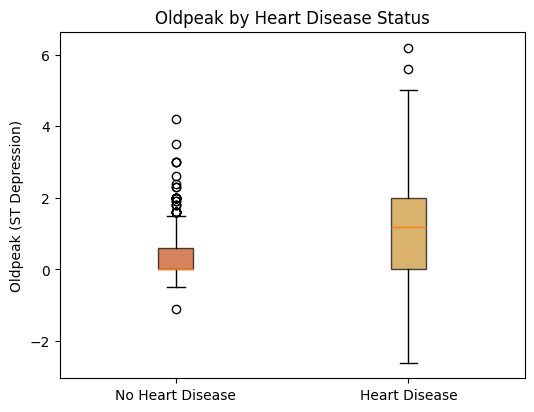

In [49]:
#Boxplot: Oldpeak by Heart Disease Status

data = [df_clean[df['HeartDisease']==0]['Oldpeak'], df_clean[df['HeartDisease']==1]['Oldpeak']]
fig, ax = plt.subplots(figsize=(6,4.5))
bp = ax.boxplot(data, tick_labels=['No Heart Disease','Heart Disease'], patch_artist=True)
for patch, c in zip(bp['boxes'], ['#C74F19', '#c9922e']):
    patch.set_facecolor(c)
    patch.set_alpha(0.7)
ax.set_ylabel('Oldpeak (ST Depression)')
ax.set_title('Oldpeak by Heart Disease Status')
plt.show()

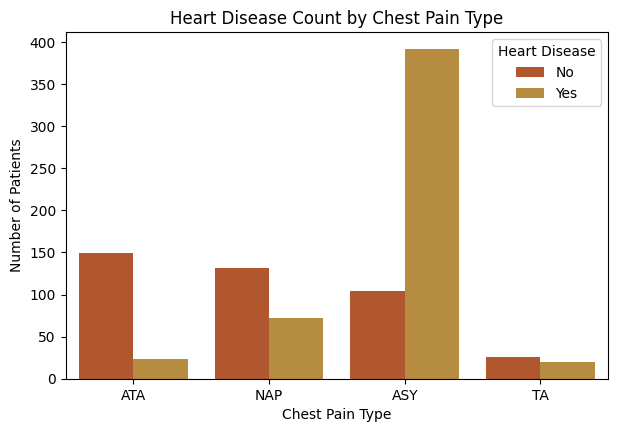

In [43]:
#Count Plot: Heart Disease by Chest Pain Type

plt.figure(figsize=(7,4.5))
sns.countplot(data=df_clean, x='ChestPainType', hue='HeartDisease', palette=['#C74F19', '#c9922e'])
plt.xlabel('Chest Pain Type')
plt.ylabel('Number of Patients')
plt.title('Heart Disease Count by Chest Pain Type')
plt.legend(title='Heart Disease', labels=['No', 'Yes'])
plt.show()

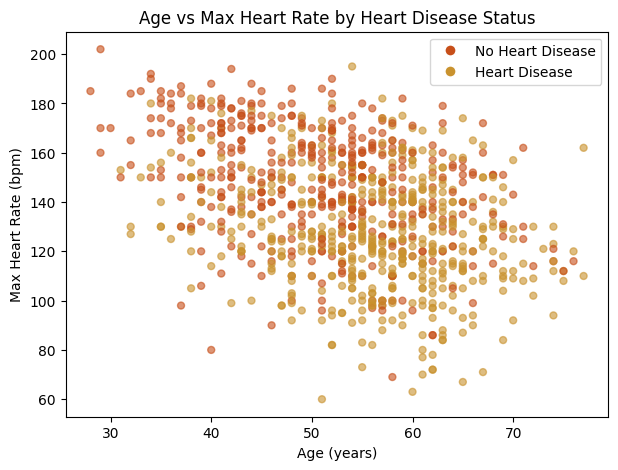

In [44]:
#Scatter Plot: Age vs Max Heart Rate

plt.figure(figsize=(7,5))
colors = df_clean['HeartDisease'].map({0: '#C74F19', 1: '#c9922e'})
plt.scatter(df_clean['Age'], df_clean['MaxHeartRate'], c=colors, alpha=0.6, s=25)
plt.xlabel('Age (years)')
plt.ylabel('Max Heart Rate (bpm)')
plt.title('Age vs Max Heart Rate by Heart Disease Status')

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#C74F19', label='No Heart Disease', markersize=8),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#c9922e', label='Heart Disease', markersize=8)
]
plt.legend(handles=legend_elements)
plt.show()